In [36]:
import numpy as np
import math
import matplotlib.pyplot as plt
from numba import njit

def energy(s, J, h):
    #2D Ising energy with periodic boundary conditions.
    
    E = 0.0
    N = s.shape[0]

    for i in range(N):
        for j in range(N):
            E -= J * s[i, j] * (
                s[(i + 1) % N, j] +
                s[i, (j + 1) % N]
            )
            E -= h * s[i, j]

    return E

@njit
def sweep_once(s, N, J, h, T, E):
    for _ in range(N * N):
        x = np.random.randint(N)
        y = np.random.randint(N)

        nn = (
            s[(x + 1) % N, y] +
            s[(x - 1) % N, y] +
            s[x, (y + 1) % N] +
            s[x, (y - 1) % N]
        )

        dE = 2 * s[x, y] * (J * nn + h)

        if dE <= 0 or np.random.rand() < math.exp(-dE / T):
            s[x, y] *= -1
            E += dE

    return E

def two_d_metropolis_ising(N, J, h, T, sweeps, warmup=None):
    if warmup is None:
        warmup = sweeps // 10

    s = np.random.choice(np.array([-1, 1]), size=(N, N))

    E = energy(s, J, h)

    # warmup
    for _ in range(warmup):
        E = sweep_once(s, N, J, h, T, E)

    energies = []
    mags = []

    for _ in range(sweeps):
        E = sweep_once(s, N, J, h, T, E)
        energies.append(E)
        mags.append(s.sum())

    return np.array(energies), np.array(mags) , s.copy()

@njit
def sweep_once_fermi(s, N, J, h, T, E):
    for _ in range(N * N):
        x = np.random.randint(N)
        y = np.random.randint(N)

        nn = (
            s[(x + 1) % N, y] +
            s[(x - 1) % N, y] +
            s[x, (y + 1) % N] +
            s[x, (y - 1) % N]
        )

        dE = 2 * s[x, y] * (J * nn + h)

        if np.random.rand() < 1/(1+ math.exp(dE / T)):
            s[x, y] *= -1
            E += dE

    return E

def glauber_ising(N, J, h, T, sweeps, warmup=None):
    if warmup is None:
        warmup = sweeps // 10

    s = np.random.choice(np.array([-1, 1]), size=(N, N))

    E = energy(s, J, h)

    # warmup
    for _ in range(warmup):
        E = sweep_once_fermi(s, N, J, h, T, E)

    energies = []
    mags = []

    for _ in range(sweeps):
        E = sweep_once_fermi(s, N, J, h, T, E)
        energies.append(E)
        mags.append(s.sum())

    return np.array(energies), np.array(mags) , s.copy()

def sim_annealing_ising(N,J,h,Tstart,Tend,alpha,sweeps_per_T):
    
    s = np.random.choice(np.array([-1, 1]), size=(N, N))

    E = energy(s, J, h)
    
    temps=[]
    energies=[]
    mags =[]
    
    T=Tstart
    
    while T > Tend:
        
        for _ in range(sweeps_per_T):
            E = sweep_once(s, N, J, h, T, E)
            
        temps.append(T)
        energies.append(E)
        mags.append(s.sum())
        
        T *= alpha
    
    return np.array(temps), np.array(energies), np.array(mags) , s.copy()


def thermo(energies, mags, J, h, T, N):
    Nspins = N * N

    E = np.mean(energies) / Nspins
    EJ = E / abs(J)

    cv = np.var(energies) / (T**2 * Nspins)

    m = np.mean(np.abs(mags)) / Nspins
    chi = np.var(mags) / (T * Nspins)

    Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))

    return {
        "Tc": Tc,
        "E per spin": E,
        "E per spin wrt J": EJ,
        "cv": cv,
        "m": m,
        "chi": chi
    }

In [45]:
Nsize = 20
Nspins = Nsize * Nsize
J = 1.0
h = 0.0

temps = np.linspace(1.8, 2.8, 40)

cv_mean = []
cv_std = []

m_mean =[]
m_std=[]

chi_mean = []
chi_std = []

E_mean = []
E_std = []

n_runs = 5

Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))
print("Critical temp")
print(Tc)

for T in temps:

    Es = []
    cvs = []
    ms = []
    chis =[]
    
    for _ in range(n_runs):

        energies, mags, _ = two_d_metropolis_ising(
            N=Nsize,
            J=J,
            h=h,
            T=T,
            sweeps=10000,
            warmup=8000
        )
        
        E = np.mean(energies) / Nspins
        Es.append(E)

        cv = np.var(energies) / (T**2 * Nsize * Nsize)
        cvs.append(cv)
        
        m = np.mean(np.abs(mags)) / Nspins
        ms.append(m)
        
        chi = np.var(mags) / (T * Nspins)
        chis.append(chi)
        
    E_mean.append(np.mean(Es))
    E_std.append(np.std(Es))

    cv_mean.append(np.mean(cvs))
    cv_std.append(np.std(cvs))
    
    m_mean.append(np.mean(ms))
    m_std.append(np.std(ms))
    
    chi_mean.append(np.mean(chis))
    chi_std.append(np.std(chis))




Critical temp
2.269185314213022


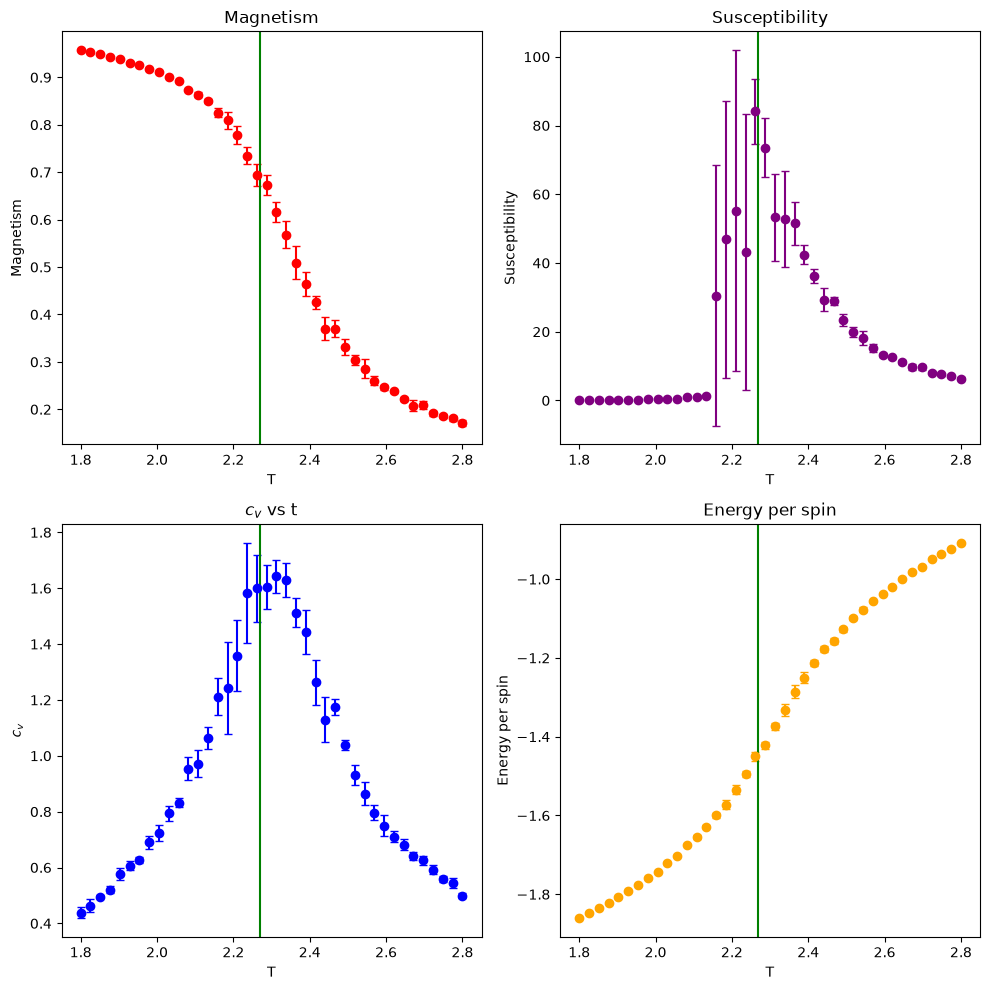

In [46]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Magnetization
ax[0,0].errorbar(
    temps, m_mean, yerr=m_std,
    fmt='o', color='red', capsize=3
)
ax[0,
   0].axvline(
    Tc,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)
ax[0,0].set_title("Magnetism")
ax[0,0].set_xlabel("T")
ax[0,0].set_ylabel("Magnetism")

# heat cap
ax[1,0].errorbar(
    temps, cv_mean, yerr=cv_std,
    fmt='o', color='blue', capsize=3
)
ax[1,0].axvline(
    Tc,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)
ax[1,0].set_title(r"$c_v$ vs t")
ax[1,0].set_xlabel("T")
ax[1,0].set_ylabel(r"$c_v$")

ax[0,1].errorbar(
    temps, chi_mean, yerr=chi_std,
    fmt='o', color='purple', capsize=3
)
ax[0,1].axvline(
    Tc,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)      
ax[0,1].set_title("Susceptibility")
ax[0,1].set_xlabel("T")
ax[0,1].set_ylabel("Susceptibility")

ax[1,1].errorbar(
    temps, E_mean, yerr=E_std,
    fmt='o', color='orange', capsize=3
)
ax[1,1].axvline(
    Tc,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)
ax[1,1].set_title("Energy per spin")
ax[1,1].set_xlabel("T")
ax[1,1].set_ylabel("Energy per spin")


plt.tight_layout()
#plt.savefig("/home/cian/Documents/college/SURE/git/QUBO/Ising/figures/met-mag-cv-chi-E.pdf")
plt.show()

In [ ]:
Nsize = 50
Nspins = Nsize * Nsize
J = 1.0
h = 0.0

temps = np.linspace(1.8, 2.8, 20)

cv_mean = []
cv_std = []

m_mean =[]
m_std=[]

n_runs = 5

Tc = 2 * abs(J) / np.log(1 + np.sqrt(2))
print("Critical temp")
print(Tc)

for T in temps:

    cvs = []
    ms = []

    for _ in range(n_runs):

        energies, mags, _ = glauber_ising(
            N=Nsize,
            J=J,
            h=h,
            T=T,
            sweeps=10000,
            warmup=8000
        )

        cv = np.var(energies) / (T**2 * Nsize * Nsize)
        cvs.append(cv)
        
        m = np.mean(np.abs(mags)) / Nspins
        ms.append(m)

    cv_mean.append(np.mean(cvs))
    cv_std.append(np.std(cvs))
    
    m_mean.append(np.mean(ms))
    m_std.append(np.std(ms))




Critical temp
2.269185314213022


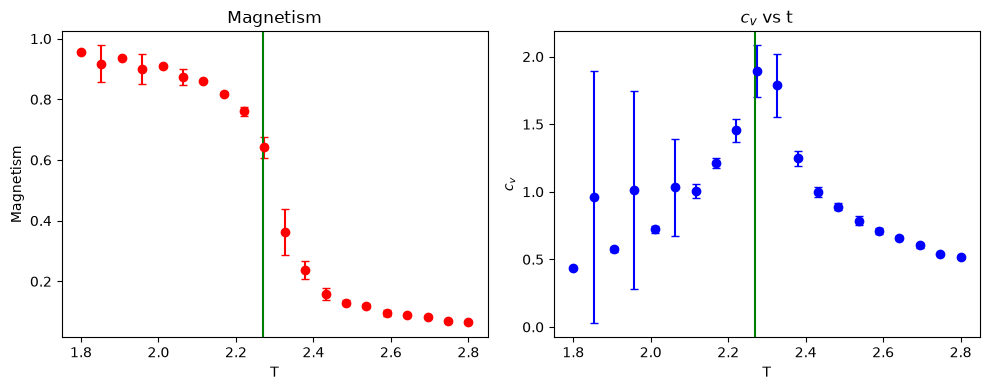

In [27]:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Magnetization
ax[0].errorbar(
    temps, m_mean, yerr=m_std,
    fmt='o', color='red', capsize=3
)
ax[0].axvline(
    Tc_onsag,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)
ax[0].set_title("Magnetism")
ax[0].set_xlabel("T")
ax[0].set_ylabel("Magnetism")

# heat cap
ax[1].errorbar(
    temps, cv_mean, yerr=cv_std,
    fmt='o', color='blue', capsize=3
)
ax[1].axvline(
    Tc_onsag,
    color='green',
    linestyle='-',
    label=fr"$T_c={Tc:.2f}$"
)
ax[1].set_title(r"$c_v$ vs t")
ax[1].set_xlabel("T")
ax[1].set_ylabel(r"$c_v$")

plt.tight_layout()
plt.show()